In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('data/airport_traffic_merged.csv')

In [3]:
display(df. info())
display(df.sample(5))
df = df.drop(columns=['FLT_DEP_IFR_2','FLT_ARR_IFR_2','FLT_TOT_IFR_2','MONTH_MON'])
display(df.describe().round())
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'])

<class 'pandas.DataFrame'>
RangeIndex: 822581 entries, 0 to 822580
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   YEAR           822581 non-null  int64  
 1   MONTH_NUM      822581 non-null  int64  
 2   MONTH_MON      822581 non-null  str    
 3   FLT_DATE       822581 non-null  str    
 4   APT_ICAO       822581 non-null  str    
 5   APT_NAME       822581 non-null  str    
 6   STATE_NAME     822581 non-null  str    
 7   FLT_DEP_1      822581 non-null  int64  
 8   FLT_ARR_1      822581 non-null  int64  
 9   FLT_TOT_1      822581 non-null  int64  
 10  FLT_DEP_IFR_2  240235 non-null  float64
 11  FLT_ARR_IFR_2  240235 non-null  float64
 12  FLT_TOT_IFR_2  240235 non-null  float64
dtypes: float64(3), int64(5), str(5)
memory usage: 81.6 MB


None

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
267029,2021,5,MAY,2021-05-31,LESO,San Sebastian,Spain,5,4,9,NaN,NaN,NaN
540404,2023,10,OCT,2023-10-21,EPSC,Szczecin - Goleniów,Poland,7,7,14,NaN,NaN,NaN
52595,2019,6,JUN,2019-06-18,LFRS,Nantes-Atlantique,France,106,107,213,NaN,NaN,NaN
393157,2022,7,JUL,2022-07-08,LFMH,Saint-Etienne-Bouthéon,France,1,1,2,NaN,NaN,NaN
360101,2022,3,MAR,2022-03-25,EETN,Tallinn,Estonia,46,49,95,45.0,48.0,93.0


,YEAR,MONTH_NUM,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1
count,822581.0,822581.0,822581.0,822581.0,822581.0
mean,2022.0,6.0,62.0,62.0,123.0
std,2.0,3.0,108.0,108.0,217.0
min,2019.0,1.0,0.0,0.0,0.0
25%,2020.0,3.0,5.0,5.0,10.0
50%,2022.0,6.0,17.0,17.0,33.0
75%,2024.0,9.0,69.0,69.0,139.0
max,2026.0,12.0,915.0,844.0,1688.0


In [4]:
display(df.duplicated().value_counts())
df[df.duplicated(keep=False)]
df = df.drop_duplicates()

False    822580
True          1
Name: count, dtype: int64

In [5]:
df.to_csv('data/clean/airport_clean.csv')

---
---

In [6]:


plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#F7F7F5",
    "axes.facecolor":   "#F7F7F5",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#DDDDDD",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlesize":   11,
    "axes.labelsize":   10,
})


df["FLT_DATE"] = pd.to_datetime(df["FLT_DATE"])
df["DOW"] = df["FLT_DATE"].dt.dayofweek  # 0=Mon, 6=Sun


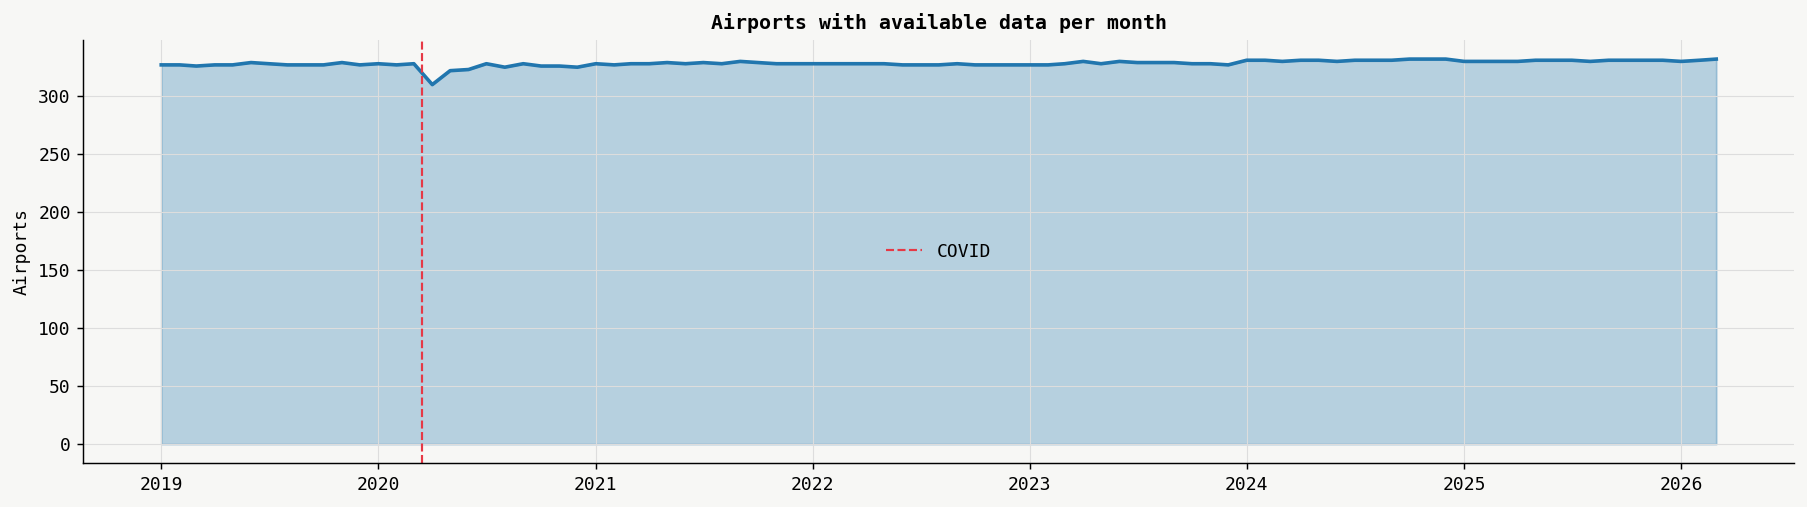

[Saved] eda_apt_01_coverage.png


In [7]:
cov = (
    df.groupby([df["FLT_DATE"].dt.to_period("M")])["APT_ICAO"]
    .nunique()
    .reset_index()
)
cov.columns = ["period", "n_airports"]
cov["date"] = cov["period"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(cov["date"], cov["n_airports"], alpha=0.3, color="#2176AE")
ax.plot(cov["date"], cov["n_airports"], color="#2176AE", lw=2)
ax.axvline(pd.Timestamp("2020-03-15"), color="#E63946", ls="--", lw=1.2, label="COVID")
ax.set_title("Airports with available data per month", fontweight="bold")
ax.set_ylabel("Airports")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("eda_apt_01_coverage.png")
plt.show()
print("[Saved] eda_apt_01_coverage.png")


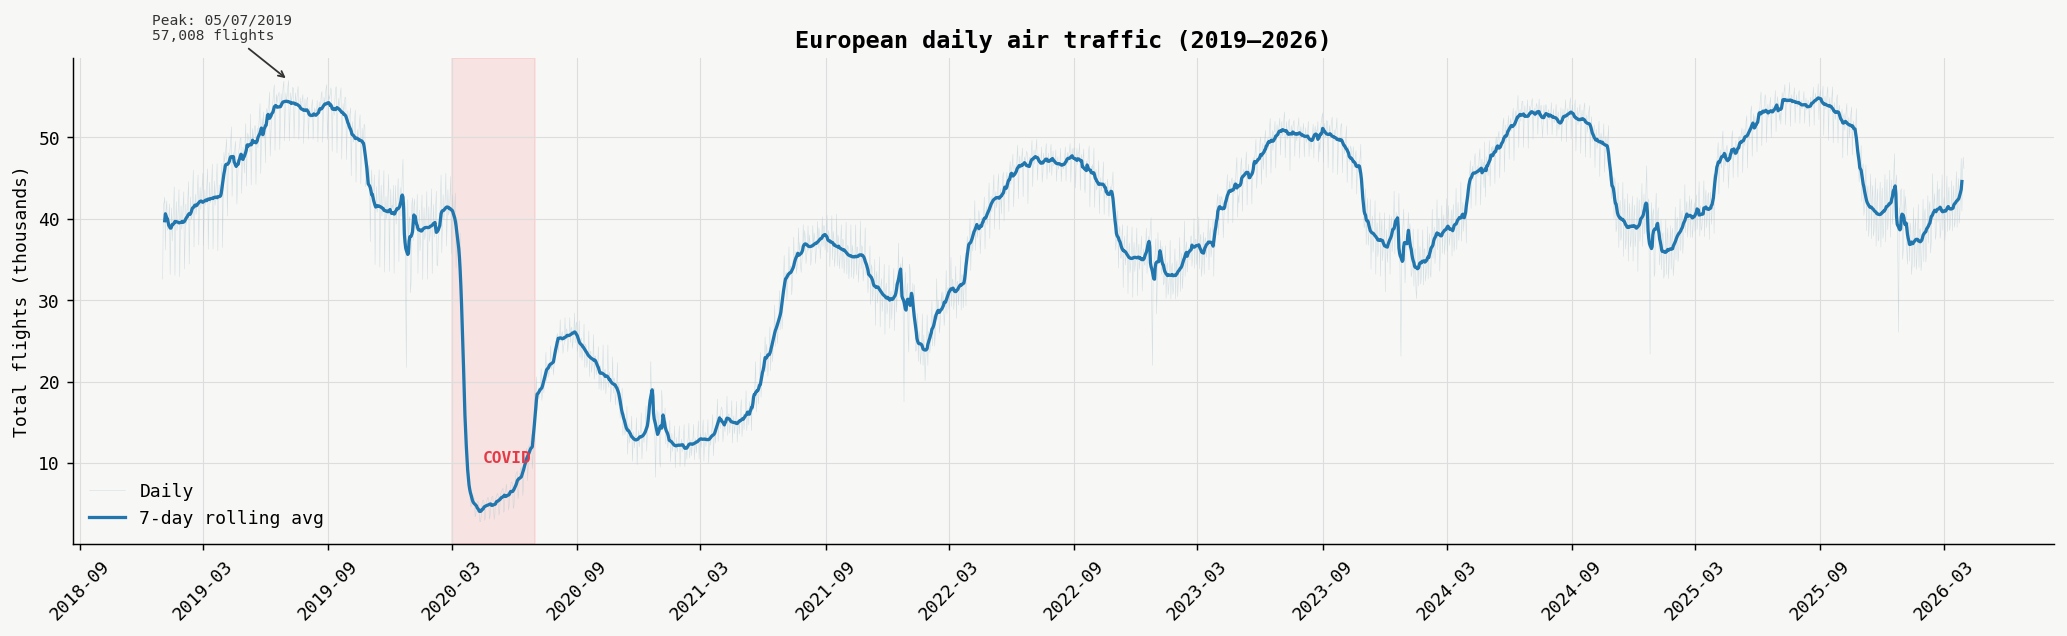

In [8]:
daily = df.groupby("FLT_DATE")["FLT_TOT_1"].sum().reset_index()
daily = daily.sort_values("FLT_DATE")
daily["rolling7"] = daily["FLT_TOT_1"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily["FLT_DATE"], daily["FLT_TOT_1"] / 1e3,
        color="#AEC6CF", lw=0.3, alpha=0.5, label="Daily")
ax.plot(daily["FLT_DATE"], daily["rolling7"] / 1e3,
        color="#2176AE", lw=1.8, label="7-day rolling avg")

# Annotations
ax.axvspan("2020-03-01","2020-07-01", alpha=0.08, color="red")
ax.annotate("COVID", xy=(pd.Timestamp("2020-04-15"), 10), fontsize=9,
            color="#E63946", fontweight="bold")

# Peak
peak_idx = daily["FLT_TOT_1"].idxmax()
peak_date = daily.loc[peak_idx, "FLT_DATE"]
peak_val  = daily.loc[peak_idx, "FLT_TOT_1"]
ax.annotate(f"Peak: {peak_date.strftime('%d/%m/%Y')}\n{peak_val:,.0f} flights",
            xy=(peak_date, peak_val/1e3),
            xytext=(peak_date - pd.Timedelta(days=200), peak_val/1e3 + 5),
            fontsize=8, arrowprops=dict(arrowstyle="->", color="#333"),
            color="#333")

ax.set_ylabel("Total flights (thousands)")
ax.set_title("European daily air traffic (2019–2026)", fontweight="bold", fontsize=13)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


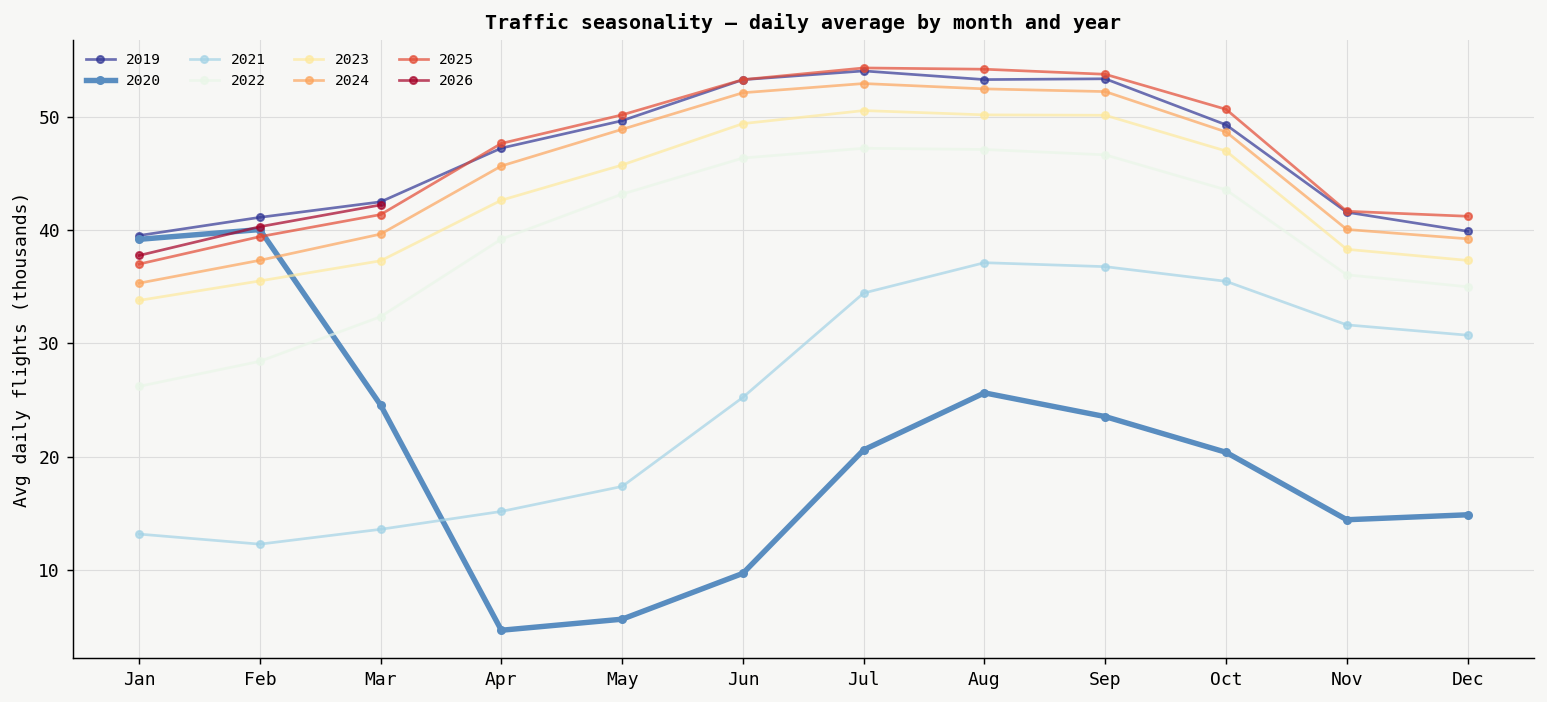

In [9]:
monthly_avg = (
    df.groupby(["YEAR","MONTH_NUM"])["FLT_TOT_1"].sum()
    .reset_index()
)
# Normalize by number of days in each month
days_in_month = df.groupby(["YEAR","MONTH_NUM"])["FLT_DATE"].nunique().reset_index()
days_in_month.columns = ["YEAR","MONTH_NUM","n_days"]
monthly_avg = monthly_avg.merge(days_in_month)
monthly_avg["daily_avg"] = monthly_avg["FLT_TOT_1"] / monthly_avg["n_days"]

piv_s = monthly_avg.pivot(index="MONTH_NUM", columns="YEAR", values="daily_avg")

fig, ax = plt.subplots(figsize=(12, 5.5))
palette_yr = cm.get_cmap("RdYlBu_r", len(piv_s.columns))
for i, yr in enumerate(piv_s.columns):
    style = {"lw": 3, "alpha": 1.0} if yr == 2020 else {"lw": 1.5, "alpha": 0.7}
    ax.plot(piv_s.index, piv_s[yr] / 1e3, marker="o", ms=4,
            color=palette_yr(i), label=str(yr), **style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("Avg daily flights (thousands)")
ax.set_title("Traffic seasonality — daily average by month and year",
             fontweight="bold")
ax.legend(ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


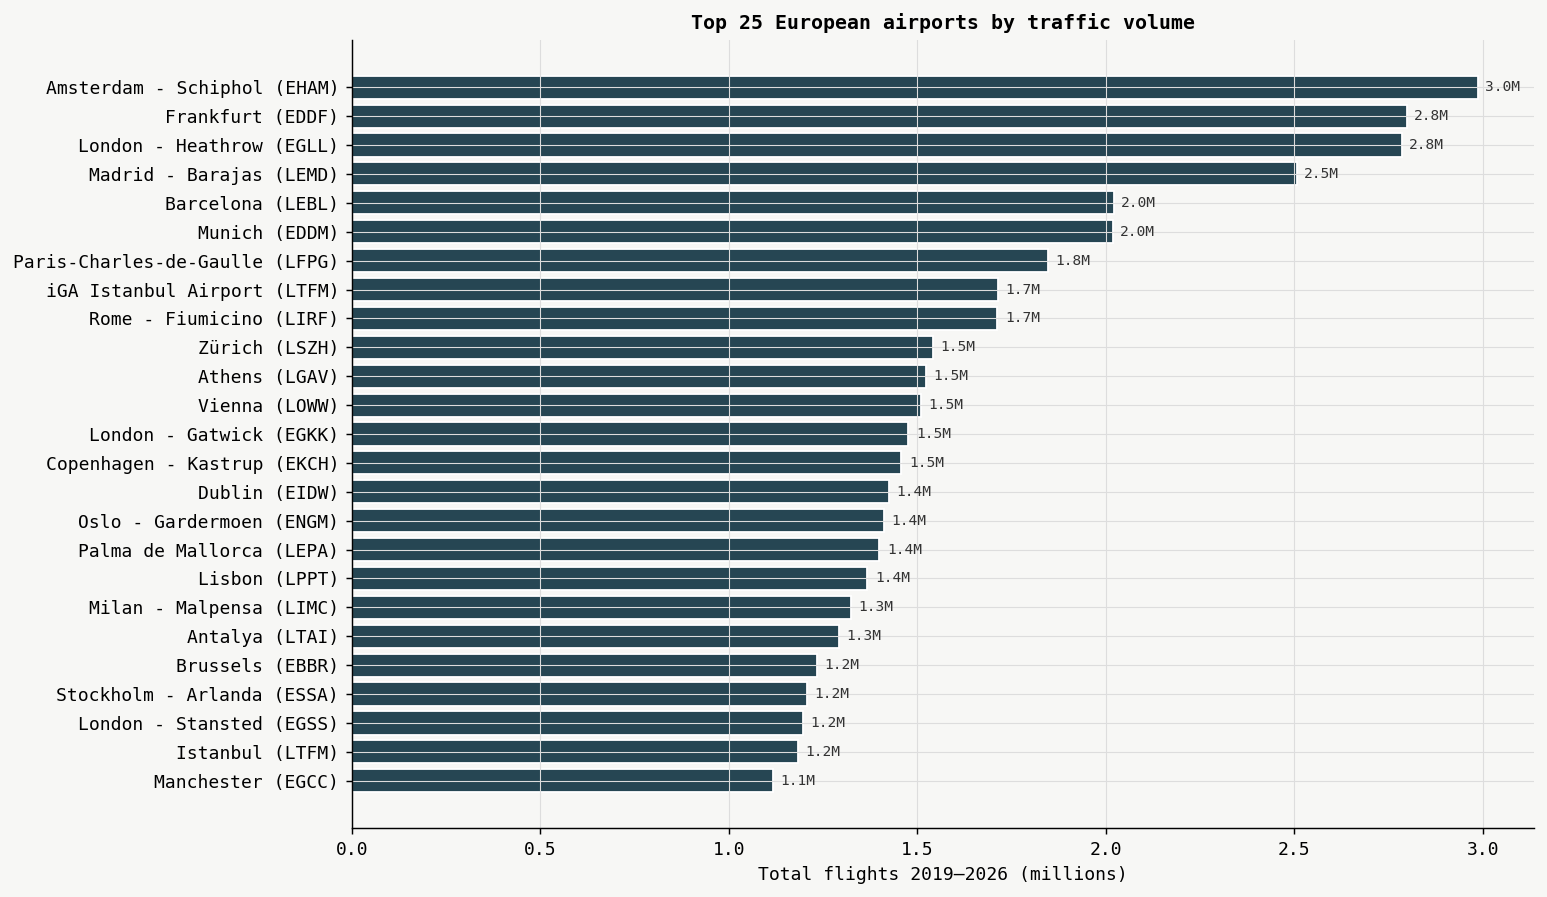

In [10]:
top20 = (
    df.groupby(["APT_ICAO","APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{row.APT_NAME} ({row.APT_ICAO})" for _, row in top20.iterrows()]
bars = ax.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Total flights 2019–2026 (millions)")
ax.set_title("Top 25 European airports by traffic volume", fontweight="bold")

for bar, val in zip(bars, top20["FLT_TOT_1"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=8, color="#333")

plt.tight_layout()
plt.show()


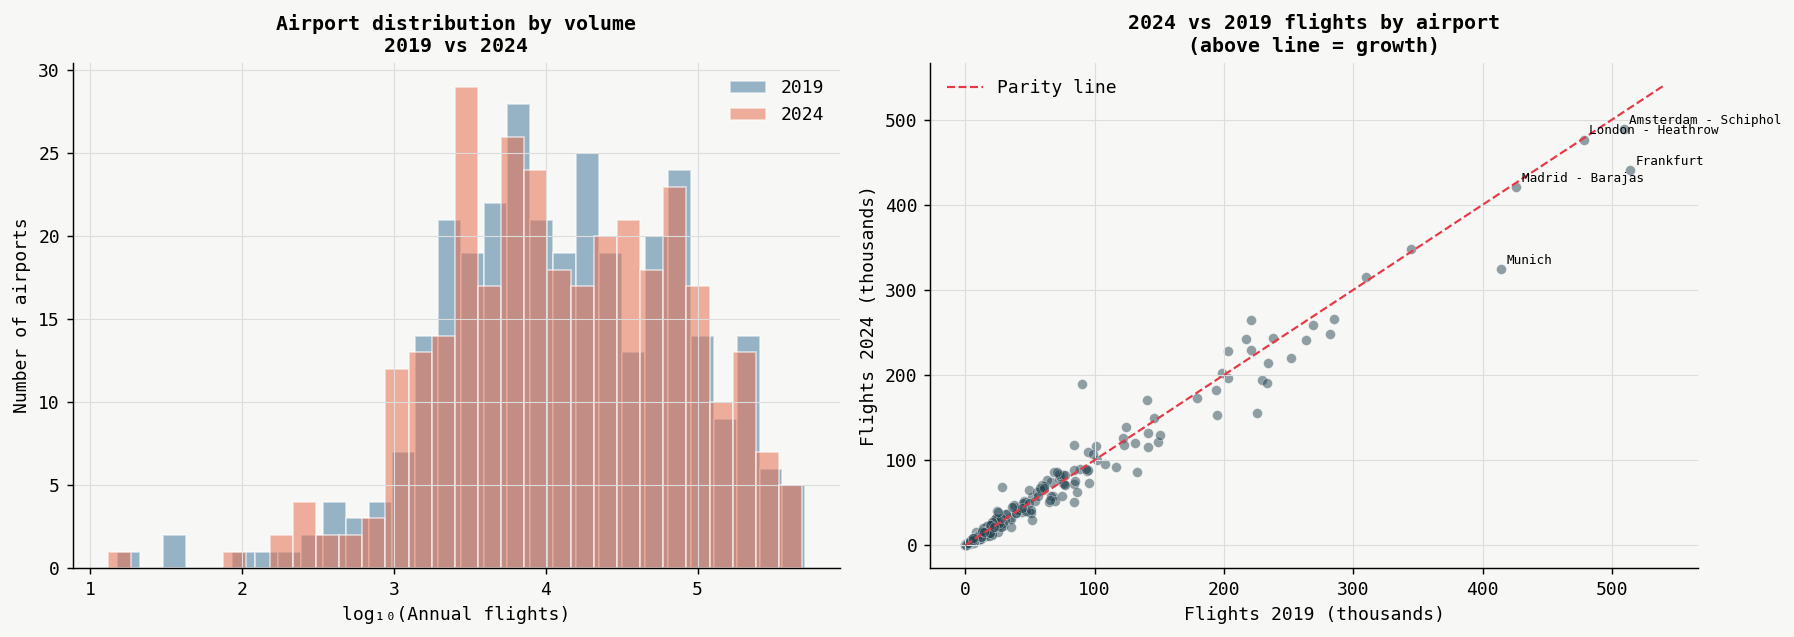

In [11]:
apt_year = df[df["YEAR"].isin([2019,2024])].groupby(
    ["APT_ICAO","APT_NAME","YEAR"]
)["FLT_TOT_1"].sum().reset_index()

apt_piv = apt_year.pivot(index=["APT_ICAO","APT_NAME"],
                          columns="YEAR", values="FLT_TOT_1").dropna()
apt_piv = apt_piv.rename(columns={2019:"y2019", 2024:"y2024"})
apt_piv["log2019"] = np.log10(apt_piv["y2019"].clip(lower=1))
apt_piv["log2024"] = np.log10(apt_piv["y2024"].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
for label, col, color in [("2019","log2019","#457B9D"),("2024","log2024","#E76F51")]:
    axes[0].hist(apt_piv[col], bins=30, alpha=0.55, color=color, label=label, edgecolor="white")
axes[0].set_xlabel("log\u2081\u2080(Annual flights)")
axes[0].set_ylabel("Number of airports")
axes[0].set_title("Airport distribution by volume\n2019 vs 2024", fontweight="bold")
axes[0].legend(frameon=False)

# Scatter 2019 vs 2024
axes[1].scatter(apt_piv["y2019"]/1e3, apt_piv["y2024"]/1e3,
                s=30, alpha=0.5, color="#264653", edgecolors="white", lw=0.3)
maxval = max(apt_piv["y2019"].max(), apt_piv["y2024"].max()) / 1e3 * 1.05
axes[1].plot([0, maxval], [0, maxval], color="#E63946", ls="--", lw=1.2,
             label="Parity line")
axes[1].set_xlabel("Flights 2019 (thousands)")
axes[1].set_ylabel("Flights 2024 (thousands)")
axes[1].set_title("2024 vs 2019 flights by airport\n(above line = growth)", fontweight="bold")
axes[1].legend(frameon=False)

# Outlier labels
apt_piv_reset = apt_piv.reset_index()
for _, r in apt_piv_reset.nlargest(5, "y2019").iterrows():
    axes[1].annotate(r["APT_NAME"], xy=(r["y2019"]/1e3, r["y2024"]/1e3),
                     fontsize=7, ha="left", xytext=(3,3), textcoords="offset points")

plt.tight_layout()
plt.show()


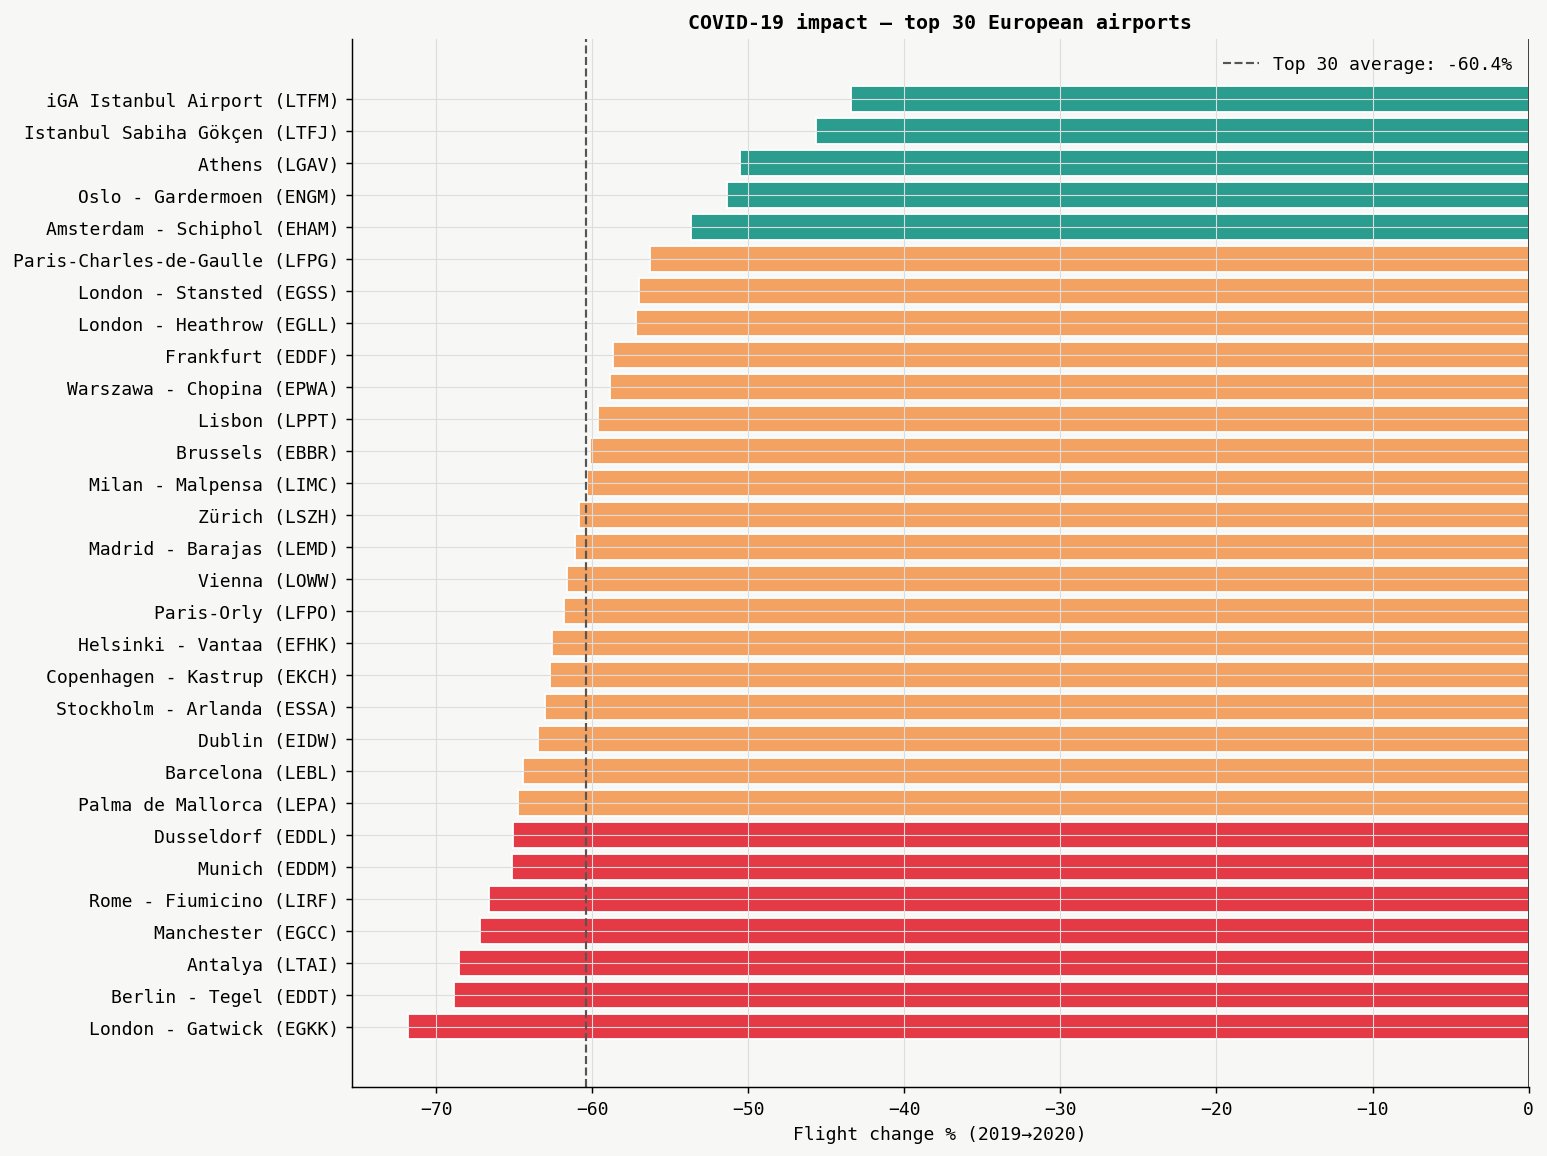

In [12]:
apt_covid_raw = df[df["YEAR"].isin([2019,2020])].groupby(
    ["APT_ICAO","APT_NAME","YEAR"]
)["FLT_TOT_1"].sum().reset_index()
apt_covid = apt_covid_raw.pivot(index=["APT_ICAO","APT_NAME"], columns="YEAR", values="FLT_TOT_1").dropna()
apt_covid = apt_covid.rename(columns={2019:"y2019", 2020:"y2020"})
apt_covid["drop_pct"] = (apt_covid["y2020"] - apt_covid["y2019"]) / apt_covid["y2019"] * 100

# Top 30 by 2019 volume
apt_covid_top = apt_covid.nlargest(30, "y2019").sort_values("drop_pct")
names = [f"{n} ({c})" for (c, n) in apt_covid_top.index]

fig, ax = plt.subplots(figsize=(12, 9))
colors_bar = ["#E63946" if v < -65 else "#F4A261" if v < -55 else "#2A9D8F"
              for v in apt_covid_top["drop_pct"]]
ax.barh(names, apt_covid_top["drop_pct"], color=colors_bar, edgecolor="white")
ax.axvline(0, color="#333", lw=1)
avg = apt_covid_top["drop_pct"].mean()
ax.axvline(avg, color="#555", ls="--", lw=1.2,
           label=f"Top 30 average: {avg:.1f}%")
ax.set_xlabel("Flight change % (2019→2020)")
ax.set_title("COVID-19 impact — top 30 European airports", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


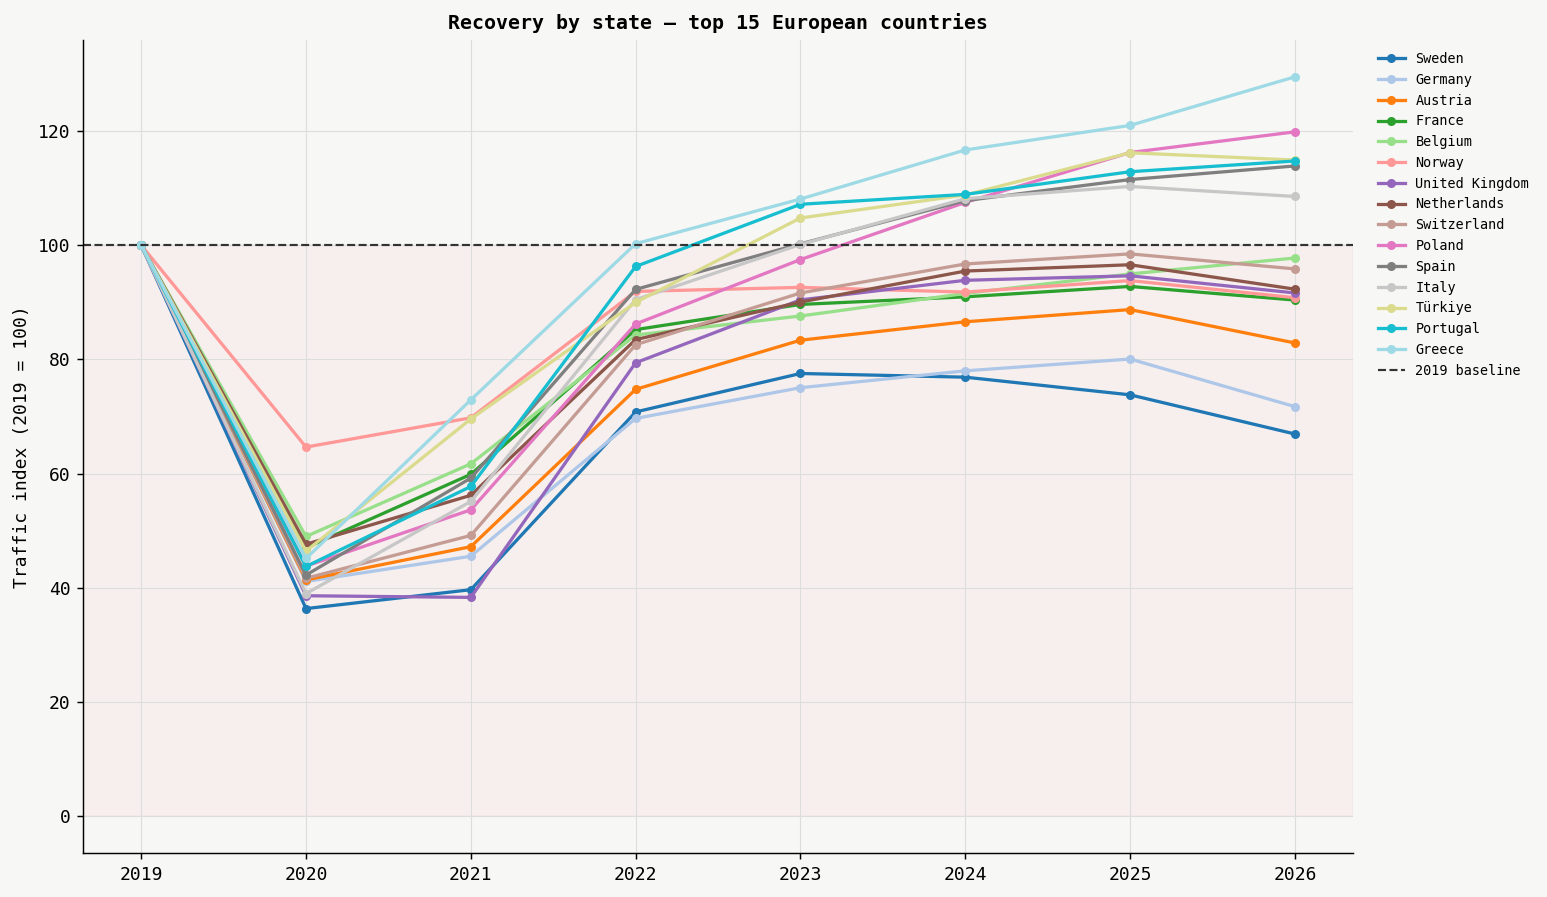

In [13]:
state_monthly = (
    df.groupby(["STATE_NAME","YEAR","MONTH_NUM"])["FLT_TOT_1"].sum()
    .reset_index()
)
# 2019 baseline per state/month
base_2019 = (
    state_monthly[state_monthly["YEAR"] == 2019]
    .rename(columns={"FLT_TOT_1":"base_2019"})
    [["STATE_NAME","MONTH_NUM","base_2019"]]
)
state_monthly = state_monthly.merge(base_2019, on=["STATE_NAME","MONTH_NUM"], how="left")
state_monthly["index_100"] = state_monthly["FLT_TOT_1"] / state_monthly["base_2019"] * 100

# Annual by state
state_annual_idx = (
    state_monthly.groupby(["STATE_NAME","YEAR"])
    .agg(tot=("FLT_TOT_1","sum"), base=("base_2019","sum"))
    .reset_index()
)
state_annual_idx["idx"] = state_annual_idx["tot"] / state_annual_idx["base"] * 100

# Top 15 states by traffic
top15_states = (
    df[df["YEAR"]==2019].groupby("STATE_NAME")["FLT_TOT_1"].sum()
    .nlargest(15).index.tolist()
)

piv_rec = state_annual_idx[state_annual_idx["STATE_NAME"].isin(top15_states)].pivot(
    index="STATE_NAME", columns="YEAR", values="idx"
)
# Sort by 2024 value
piv_rec = piv_rec.sort_values(2024, ascending=True) if 2024 in piv_rec.columns else piv_rec

fig, ax = plt.subplots(figsize=(12, 7))
palette_st = cm.get_cmap("tab20", len(piv_rec))
for i, state in enumerate(piv_rec.index):
    row = piv_rec.loc[state].dropna()
    ax.plot(row.index, row.values, marker="o", ms=4,
            color=palette_st(i), lw=1.8, label=state)

ax.axhline(100, color="#333", ls="--", lw=1.2, label="2019 baseline")
ax.axhspan(0, 100, alpha=0.04, color="#E63946")
ax.set_ylabel("Traffic index (2019 = 100)")
ax.set_title("Recovery by state — top 15 European countries", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7.5, frameon=False)
plt.tight_layout()
plt.show()


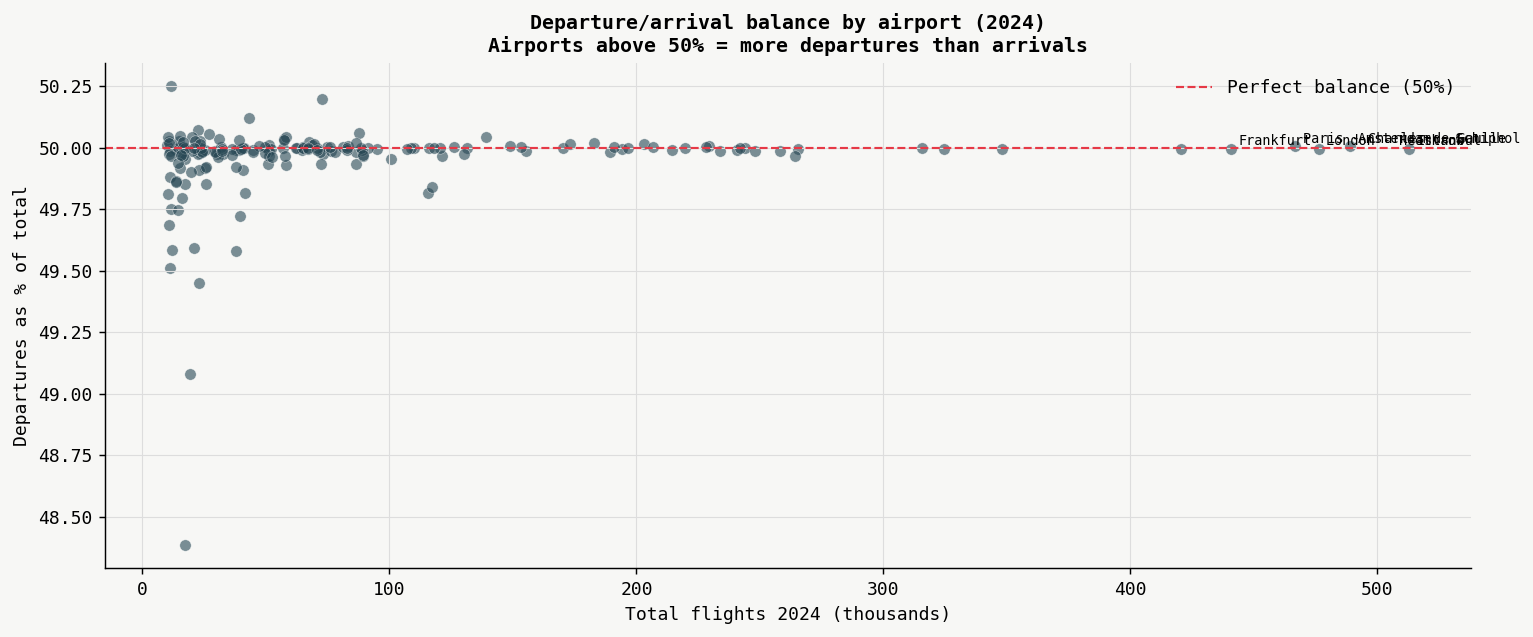

In [14]:
apt_ratio = (
    df[df["YEAR"] == 2024]
    .groupby(["APT_ICAO","APT_NAME"])[["FLT_DEP_1","FLT_ARR_1","FLT_TOT_1"]]
    .sum()
    .reset_index()
)
apt_ratio["dep_share"] = apt_ratio["FLT_DEP_1"] / apt_ratio["FLT_TOT_1"] * 100
apt_ratio = apt_ratio[apt_ratio["FLT_TOT_1"] >= 10000]  # significant airports only

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(apt_ratio["FLT_TOT_1"] / 1e3,
                apt_ratio["dep_share"],
                s=40, alpha=0.6, c="#264653", edgecolors="white", lw=0.3)
ax.axhline(50, color="#E63946", ls="--", lw=1.2, label="Perfect balance (50%)")
ax.set_xlabel("Total flights 2024 (thousands)")
ax.set_ylabel("Departures as % of total")
ax.set_title("Departure/arrival balance by airport (2024)\n"
             "Airports above 50% = more departures than arrivals", fontweight="bold")
ax.legend(frameon=False)

# Label extremes
extremes = apt_ratio.nlargest(5, "FLT_TOT_1")
for _, r in extremes.iterrows():
    ax.annotate(r["APT_NAME"], xy=(r["FLT_TOT_1"]/1e3, r["dep_share"]),
                fontsize=7.5, ha="left", xytext=(4,2), textcoords="offset points")

plt.tight_layout()
plt.show()


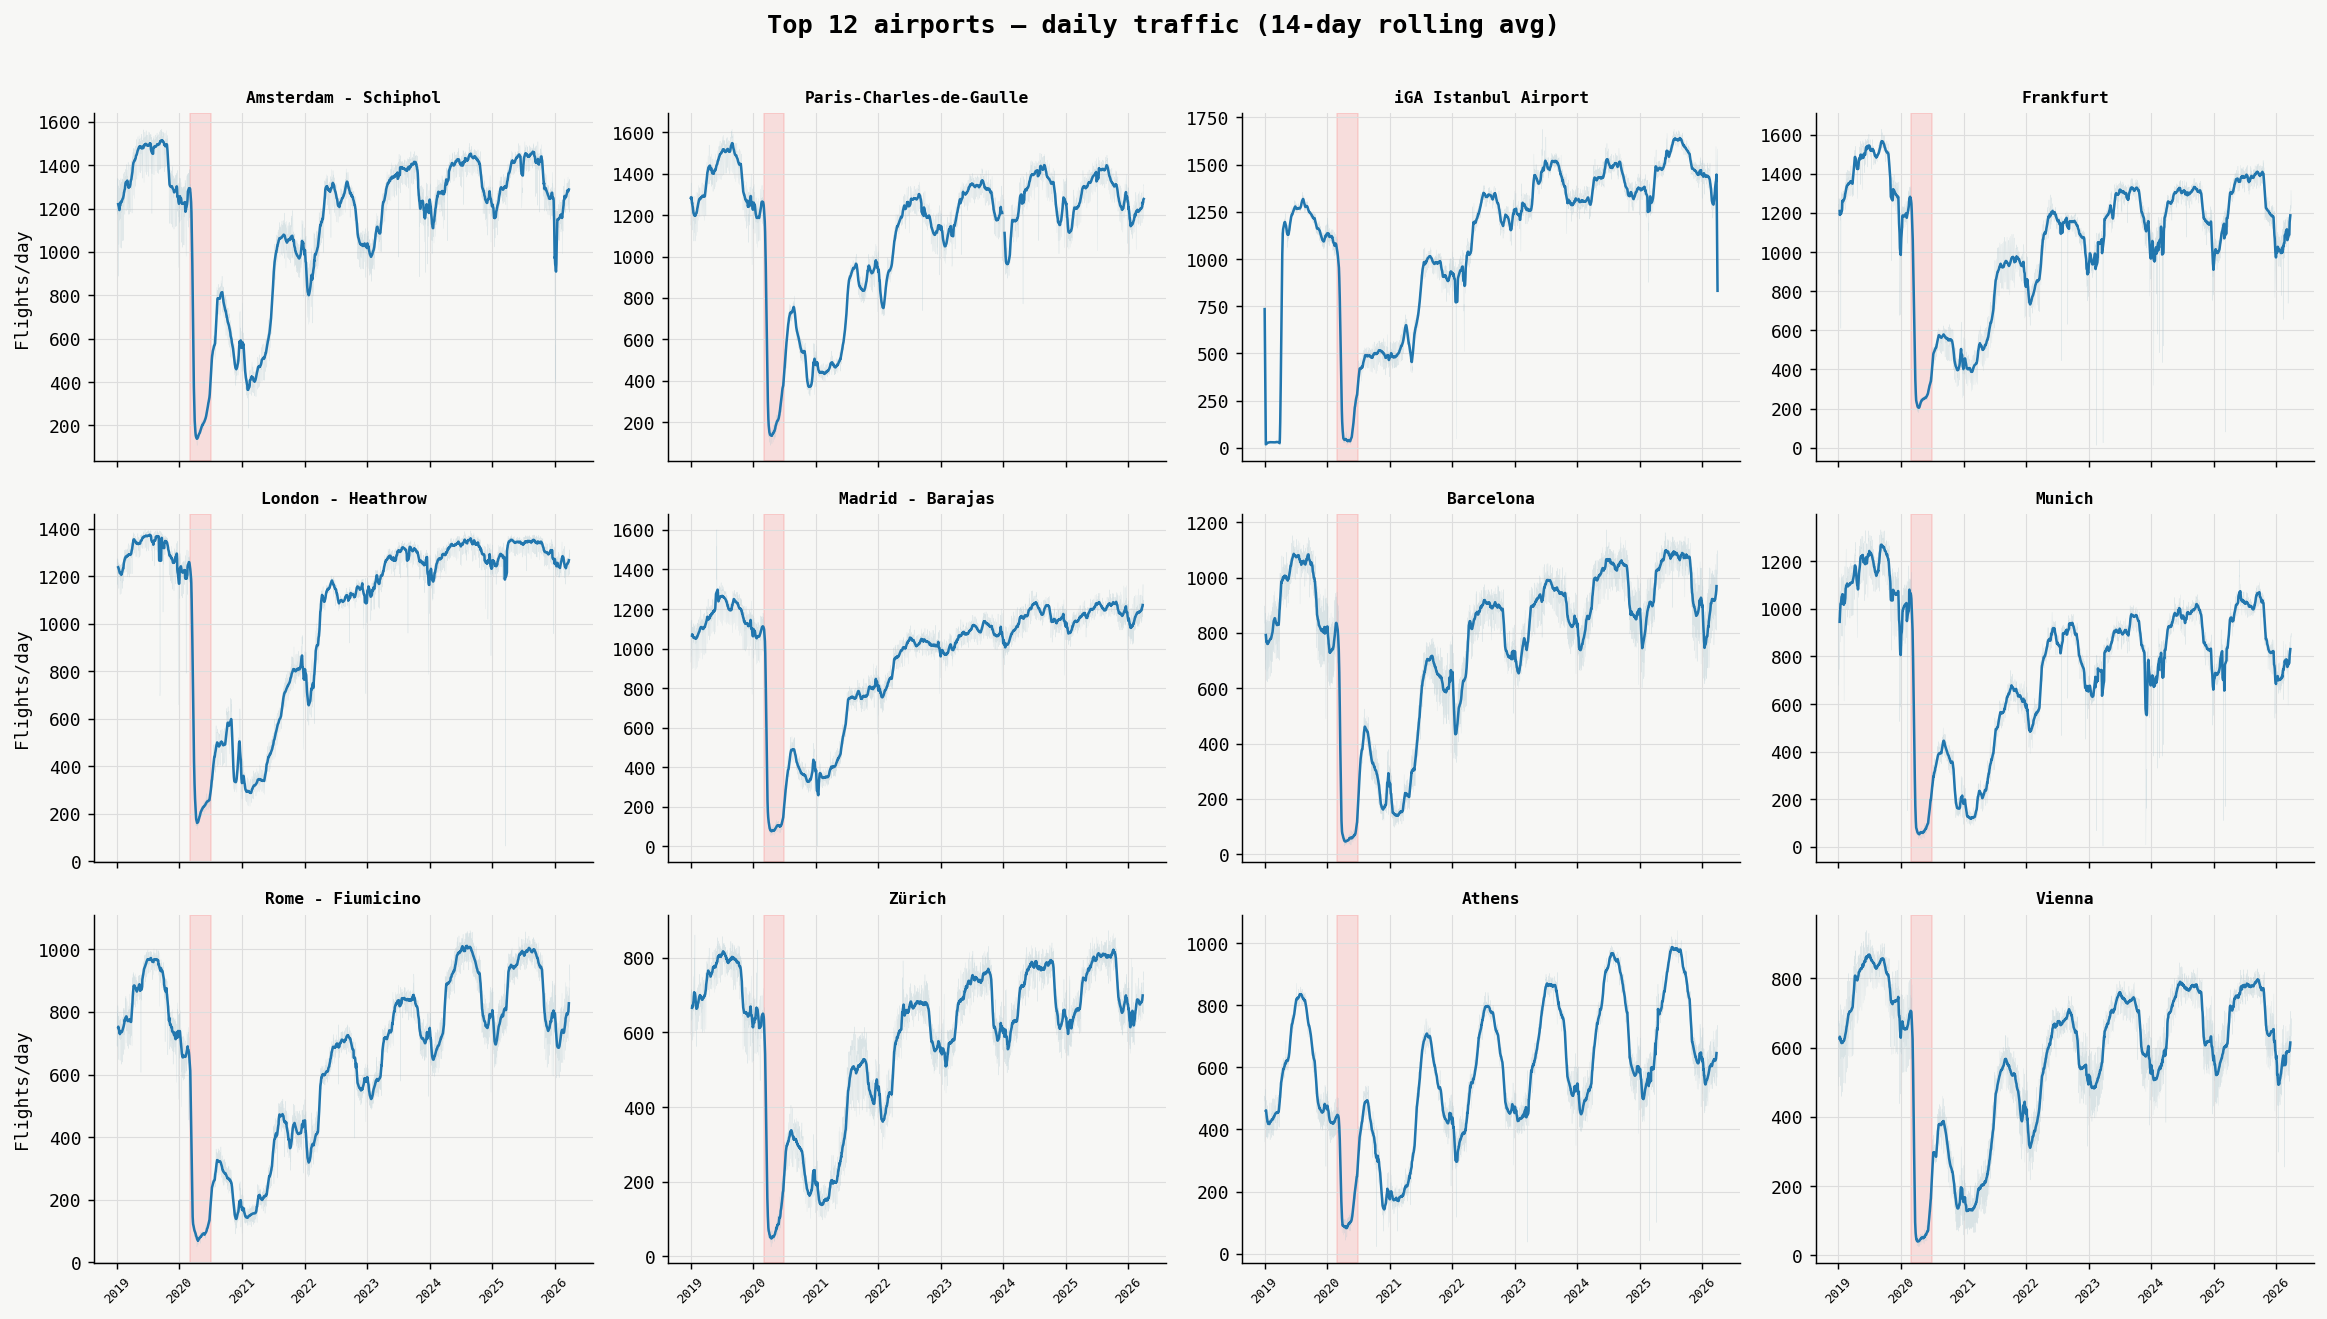

In [15]:
top12_codes = (
    df.groupby("APT_ICAO")["FLT_TOT_1"].sum()
    .nlargest(12).index.tolist()
)
sm = df[df["APT_ICAO"].isin(top12_codes)].copy()
sm_daily = sm.groupby(["APT_ICAO","APT_NAME","FLT_DATE"])["FLT_TOT_1"].sum().reset_index()
sm_daily["rolling"] = (
    sm_daily.groupby("APT_ICAO")["FLT_TOT_1"]
    .transform(lambda s: s.rolling(14, center=True).mean())
)

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True)
axes_flat = axes.flatten()

for i, code in enumerate(top12_codes):
    ax = axes_flat[i]
    sub = sm_daily[sm_daily["APT_ICAO"] == code].sort_values("FLT_DATE")
    name = sub["APT_NAME"].iloc[0]
    ax.plot(sub["FLT_DATE"], sub["FLT_TOT_1"],
            color="#AEC6CF", lw=0.2, alpha=0.4)
    ax.plot(sub["FLT_DATE"], sub["rolling"],
            color="#2176AE", lw=1.4)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-07-01"),
               alpha=0.1, color="red")
    ax.set_title(f"{name}", fontweight="bold", fontsize=9)
    if i % 4 == 0:
        ax.set_ylabel("Flights/day")

for ax in axes_flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Top 12 airports — daily traffic (14-day rolling avg)",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


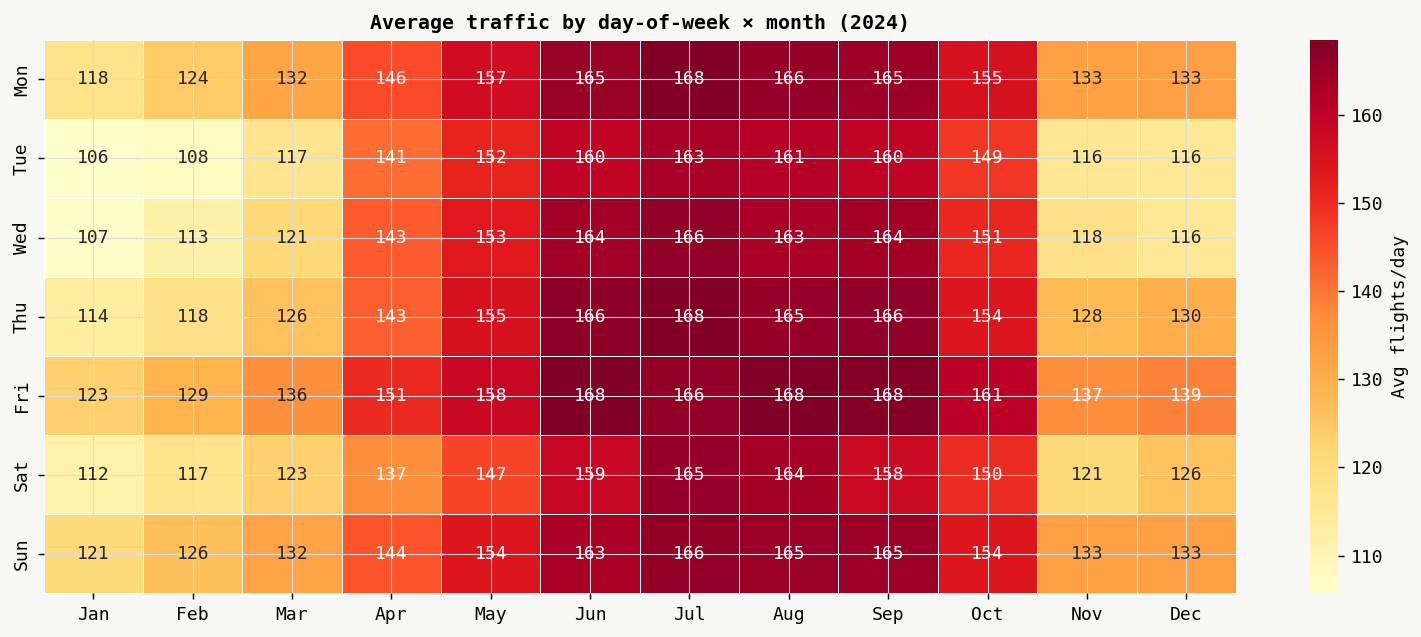

In [16]:
hw = df[df["YEAR"] == 2024].copy()
hw_agg = hw.groupby(["DOW","MONTH_NUM"])["FLT_TOT_1"].mean().reset_index()
hw_piv = hw_agg.pivot(index="DOW", columns="MONTH_NUM", values="FLT_TOT_1")

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
mon_labels = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(hw_piv, annot=True, fmt=",.0f", cmap="YlOrRd",
            xticklabels=mon_labels, yticklabels=dow_labels,
            ax=ax, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Avg flights/day"})
ax.set_title("Average traffic by day-of-week × month (2024)",
             fontweight="bold")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
plt.show()
